# Harmonics:

The expression for the field harmonics is given by:
* $\large{b_n=10^4\cdot \left(\dfrac{R_0}{a}\right)^n \cos[(n+1)\phi]}$

The expression for the integral field harmonics are:
* $\large{B_n=10^4\cdot L \cdot \left(\dfrac{R_0}{a}\right)^n \cos[(n+1)\phi]=b_n\cdot L}$

In [ ]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [ ]:
def Harmonic(R0, a, phi, n):
    harm = (10**4) * ((R0/a)**n) * np.cos((n+1)*phi)
    return harm

In [ ]:
n_list = [0, 1, 2, 3, 4]
harms = []
for pole in n_list:
    harms.append(Harmonic(5, 7, np.pi/4, pole))

print(harms)

[[2.0, 2.3, 2.6, 2.9, 3.2]]
[[2.0, 2.3, 2.6, 2.9, 3.2], [3.5, 3.8, 4.1, 4.4, 4.7, 5.0]]
[[2.0, 2.3, 2.6, 2.9, 3.2], [3.5, 3.8, 4.1, 4.4, 4.7, 5.0], [5.3, 5.6]]
Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]: [-2279061.059067 -0.000000 8948.383987 -0.000000 6121.680009]
Relative to main: [1.000000 0.000000 -0.003926 0.000000 -0.002686]
Harmonics in 10^4 units: [10000.000000 0.000000 -39.263468 0.000000 -26.860535]


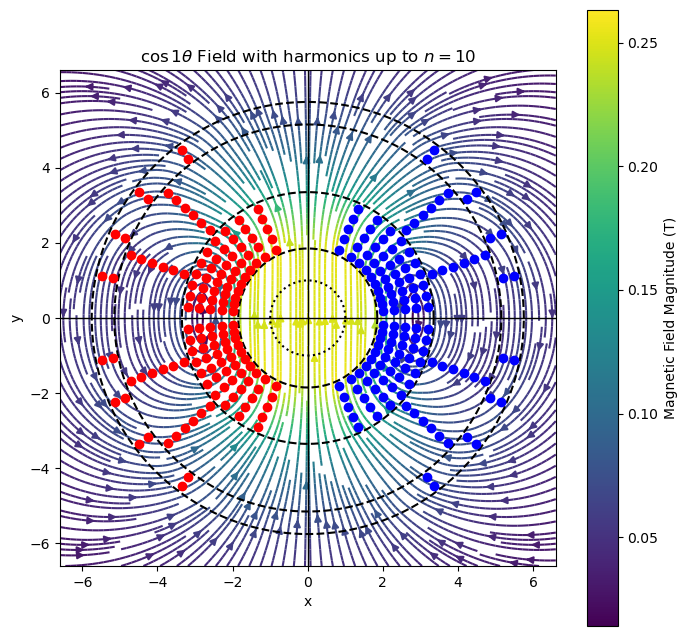

1.85
3.35
CPU times: total: 36.3 s
Wall time: 36.4 s


In [1]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Sets np values to not auto print in scientific notation for small numbers
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})
#import matplotlib
#matplotlib.use('TkAgg')  # Or 'Qt5Agg', 'WebAgg', etc.

# Max harmonic we want the calculation to go up to:
# 1 = dipole, 2 = quadrupole, 3 = sextupole, etc.
n_max = 10
# Current magnitude
I0 = 16000
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7
# Radius from origin as starting point (inner layer)
# Outter radius is controlled by amount of condutors present in block

# Reference Radius (Good Field Region): -> No calculations are done here yet, this is just for visualization
ref_rad = 1
# Aperture radius:
r0 = 2
# Radial spacing between conductors
dr = 0.3 
# Inner wall radius
inner_radius = r0 - dr/2
# The type of magnet: 1=Dipole, 2=Quardupole, 3=Sextupole, etc.
mag_type = 1

# Number of "wires" in each layer section (cable)
n_radial = [5, 6, 2]

# Total number of blocks (divide by 4 to get number of blocks per quadrant) for each layer

# A list of the numbers of conductors in each layer:
num_cond_quad = [10, 2, 4] # Rename to "cables"


# First layer radius:
outer_radius = (r0 + (n_radial[0] - 1) * dr) + dr/2

# Number of conductors per layer:
num_conductors = 4*num_cond_quad
    

# 2nd layer radius
# n layer = inner_radius + n*(outer_radius-inner_radius)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    #a = np.sqrt(x_a**2 + y_a**2)
    a = np.hypot(x_a, y_a)
    # Position of field measurement
    #r = np.sqrt(x**2 + y**2)
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> # If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y


# List of angles following a cosine theta distribution, symmetric about y axis

# Uniformly spaced cumulative values (excluding 0 and 1 to avoid endpoints)
u_list = []
for i in range(len(num_cond_quad)):
    u_list.append(np.linspace(0, 1, num_cond_quad[i] + 2)[1:-1])


def phi_list_maker(u, mag_type): # Angle of the conductor so actually phi!!!
    # ensure array + safe domain for arcsin
    #u = np.asarray(u, dtype=float)
    #eps = np.finfo(float).eps
    #u = np.clip(u, 0.0 + eps, 1.0 - eps)

    if mag_type == 1:  # Dipole: 
        phi_right = np.arcsin(u)

    elif mag_type == 2:  # Quadrupole: 
        theta_right = np.empty_like(u)
    
        # Split into lower and upper halves of the CDF
        lower_half = (u <= 0.5)
        upper_half = ~lower_half
    
        # Map u -> theta for each region
        theta_right[lower_half] = 0.5 * np.arcsin(2 * u[lower_half])
        theta_right[upper_half] = 0.5 * np.pi -0.5 * np.arcsin(2 * (1 - u[upper_half]))

    else:
        raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")

    # Mirror to other quadrants
    phi_left      = np.pi - phi_right
    phi_bot_left  = -phi_left
    phi_bot_right = -phi_right

    phi_list = np.sort(np.concatenate([phi_right, phi_left, phi_bot_left, phi_bot_right]))
    return phi_list



# Creates a master list of the theta distributions for each layer:
parent_phi_list = []
for i in range(len(u_list)):
    parent_phi_list.append(phi_list_maker(u_list[i], mag_type))


# Determines the position of the conductors from the given angles

# Determines the radial position of each layer group of conductors in each layer
# Recall: n_radial = [5, 6, 2] -> Number of "wires" in each layer section (cable)
layer_radii = []
for j in range(len(n_radial)):
    if j == 0: # First layer radii values
        layer_radii.append( [r0 + i * dr for i in range(n_radial[0])] )
    else: # All other layer radii values, adds to the top of the last layer
        layer_radii.append( [(layer_radii[j-1][-1] + dr + i * dr) for i in range(n_radial[j])] ) 
    print(layer_radii)

###################
"""
# The Harmonic contributuions for each n due to a conductor at (a, phi)
def Harmonic(R0, a, phi, n):
    harm = (mu0*I0/2*np.pi) * (10**4) * ((R0/a)**n) * np.cos((n+1)*phi)
    return harm
"""
# Takes into account the current:
def Harmonic(R0, a, phi, n, I_wire):
    # You can drop mu0*I0/(2π) if you only care about relative sizes;
    # what matters is the SIGN of I_wire.
    return I_wire * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)

# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.

# For a dipole, even harmonics are not allowed, so here we just look at odd constributions

"""
We want to find the sum of each n contribution
So:
Calculate the n harmonic due to each conductor
Then sum up these contributions to get the total contribution for each conductor
    
# For each n, calculate the harmonics from each conductor then sum them up
# Should have a list with the same length as n_list

"""
"""
def Total_Harms(theta_list, radii_list): # Want the sum of each n contribution
    total_harms = []
    for n in n_list:
        temp = []
        for theta in theta_list:
            for r in radii_list:
                temp.append( Harmonic(r0, r, theta, n) )
        # After we calculate for each condcutor, we sum up the total for that n
        summ = np.sum(temp)
        total_harms.append(summ)
    print(total_harms)
    return total_harms
"""
def Total_Harms_from_wires(wire_param_list, n_list, R0):
    totals = np.zeros(len(n_list)) # Need to intialize to add to the initial zero, otherwise throws an error
    for (xw, yw, Iw) in wire_param_list:
        a   = np.hypot(xw, yw)
        phi = np.arctan2(yw, xw)
        for j, n_val in enumerate(n_list):
            totals[j] += Harmonic(R0, a, phi, n_val, np.sign(Iw))  # sign of current matters
    return totals


# Need to make a plot of contributions as a function of theta in the first quadrant

####################

# Maps out the wires and how they should be distributed
# Current stays constant in magntitude for each conductor

def wire_params(phi_list, radii_list): # Calculate harmonics here, as this is where the conductor position is defined
    wire_params = []
    for phi in phi_list:
        for r in radii_list:
            # Wire locations
            x = r * np.cos(phi)
            y = r * np.sin(phi)
            
            if mag_type == 1:  # Dipole 
                current = -I0 if x > 0 else (I0 if x < 0 else 0)

            elif mag_type == 2:  # Quadrupole (+ on ±x, − on ±y)
                c = np.cos(2 * theta)
                current = I0 if c > 0 else (-I0 if c < 0 else 0)

            elif mag_type == 3:  # Sextupole: alternate every 60° via cos(3θ)
                c = np.cos(3 * theta)
                current = I0 if c > 0 else (-I0 if c < 0 else 0)

            else:
                raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")
            
            wire_params.append((x, y, current))
    return wire_params


# Make a wire params parent list via looping here

layer_harm_contrib = []
total_wire_params = []
for i in range(len(layer_radii)):
    total_wire_params.append(wire_params(parent_phi_list[i], layer_radii[i]))

# B-field components are computed
# We set them up as arrays with the same dimensions as X and Y

# bounds = [ x min & max, y min & max ]
# Used for both field calculation and plotting to minimize computation

# Auto-sets the bounds based on the outer layer's radius
bounds = [ [(-1)*(layer_radii[i][-1]+1), layer_radii[i][-1]+1], [(-1)*(layer_radii[i][-1]+1), layer_radii[i][-1]+1] ]

# Bounds for first quadrant only:
#bounds =  [ [0, layer_radii[i][-1]+1], [0, layer_radii[i][-1]+1] ]

# Automatically set bounds to allow viewing of all layers

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

#iterate over wire params parent list
# Calculate field for each wire component

for params in total_wire_params:
    for x0, y0, I in params:
        Bx, By = B_harm(X, Y, x0, y0, I)
        Bx_total += Bx
        By_total += By

# Total B-field magnitudes are computed
#B_mag = np.sqrt(Bx_total**2 + By_total**2)
B_mag = np.hypot(Bx_total, By_total)


# For first layer distribution
#Total_Harms(parent_theta_list[0], layer_radii[0])
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole
B_main_index = mag_type - 1 # From the magtype definition, sets main field to whatever the magnet type is set to

# Calculates the total harmonics taking into account each layer
all_wires = []
for layer in total_wire_params:
    for wire in layer:
        all_wires.append(wire)

harms = Total_Harms_from_wires(all_wires, n_list, ref_rad)

print("Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)

####################################################################################
# Plotting

plt.figure(figsize=(8, 8))

# Stream plot of magnetic field
# Only shows 95th percentile as max to make line magnitudes easier to see
#norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

for params in total_wire_params:
    for x0, y0, I in params:
        color = 'r' if I > 0 else 'b'
        plt.plot(x0, y0, 'o', color=color, zorder=2)

# Defines the angular space to plot the cirles
theta_circle = np.linspace(0, 2*np.pi, 500)

# Plot of the reference radius
x_ref = ref_rad * np.cos(theta_circle)
y_ref = ref_rad * np.sin(theta_circle)
plt.plot(x_ref, y_ref, 'k:', zorder=1)

# Draw inner circle
x_circle = inner_radius * np.cos(theta_circle)
y_circle = inner_radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=1)

# Draw outer circle to contain all conductors (defined by number of conductors)
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=1)

# Radius = last point + dr
for i in range(len(layer_radii)):
    if i == 0: # Skip the first layer since that plots earlier
        pass
    else: # Prints other layer radii
        x_layer = (layer_radii[i][-1]+dr/2) * np.cos(theta_circle) # The [-1] index accesses the last value in the list
        y_layer = (layer_radii[i][-1]+dr/2) * np.sin(theta_circle)
        plt.plot(x_layer, y_layer, 'k--', zorder=1)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"$\\cos {mag_type}\\theta$ Field with harmonics up to $n=${n_max}")
plt.show()

print(inner_radius)
print(outer_radius)